In [ ]:
import sys
sys.path.append("../scripts")

In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import binned_statistic
import niceplots
from seaborn import color_palette

In [3]:
niceplots.initPlot()
Cs = color_palette("colorblind")
Cs

[(0.00392156862745098, 0.45098039215686275, 0.6980392156862745),
 (0.8705882352941177, 0.5607843137254902, 0.0196078431372549),
 (0.00784313725490196, 0.6196078431372549, 0.45098039215686275),
 (0.8352941176470589, 0.3686274509803922, 0.0),
 (0.8, 0.47058823529411764, 0.7372549019607844),
 (0.792156862745098, 0.5686274509803921, 0.3803921568627451),
 (0.984313725490196, 0.6862745098039216, 0.8941176470588236),
 (0.5803921568627451, 0.5803921568627451, 0.5803921568627451),
 (0.9254901960784314, 0.8823529411764706, 0.2),
 (0.33725490196078434, 0.7058823529411765, 0.9137254901960784)]

In [4]:
Cp = color_palette("Paired")
Cp

[(0.6509803921568628, 0.807843137254902, 0.8901960784313725),
 (0.12156862745098039, 0.47058823529411764, 0.7058823529411765),
 (0.6980392156862745, 0.8745098039215686, 0.5411764705882353),
 (0.2, 0.6274509803921569, 0.17254901960784313),
 (0.984313725490196, 0.6039215686274509, 0.6),
 (0.8901960784313725, 0.10196078431372549, 0.10980392156862745),
 (0.9921568627450981, 0.7490196078431373, 0.43529411764705883),
 (1.0, 0.4980392156862745, 0.0),
 (0.792156862745098, 0.6980392156862745, 0.8392156862745098),
 (0.41568627450980394, 0.23921568627450981, 0.6039215686274509),
 (1.0, 1.0, 0.6),
 (0.6941176470588235, 0.34901960784313724, 0.1568627450980392)]

In [48]:
from meer21cm import util
from meer21cm.plot import plot_map
from meer21cm import PowerSpectrum
from meer21cm.power import get_modelpk_conv, bin_3d_to_cy
from specs import *
from classy_wraper_for_m21cm import *
import scipy.signal.windows as windows


In [49]:
data = np.load("../data/power_spectra_full_sims.npz")

Build k space

In [50]:
kmode = data["kmode"]
kmask = ~(kmode==0.0) # we can be more carefull and extract a scalecut with pca

kmin = np.min(kmode[kmask])
kmax = np.max(kmode[kmask])
Nk = 20

kedges = np.geomspace(kmin, kmax, Nk)
kcenter = np.sqrt(kedges[1:] * kedges[:-1])

N, _, _ = binned_statistic(kmode[kmask], [], "count", kedges)
Nmask = ~(N==0)

kcenter = kcenter[Nmask]

Compute the 1d averages Ps for now

In [51]:
def extract_mean(pk):
    Pk_3d = data[pk]
    Pk_mean = np.percentile(Pk_3d, 50,axis=0)
    Pk_1d, _, _ = binned_statistic(kmode[kmask], Pk_mean[kmask], "mean", kedges)

    return Pk_1d[Nmask]

In [52]:
Pkhi = extract_mean("phi")
Pkgal = extract_mean("pgal")
Pkhixgal = extract_mean("phixgal")
Pknoise = extract_mean("pnoise")

Text(0, 0.5, '$P^{XY}(k)\\,(b_X\\,b_Y)^{-1}\\,[\\mathrm{arb. units}]$')

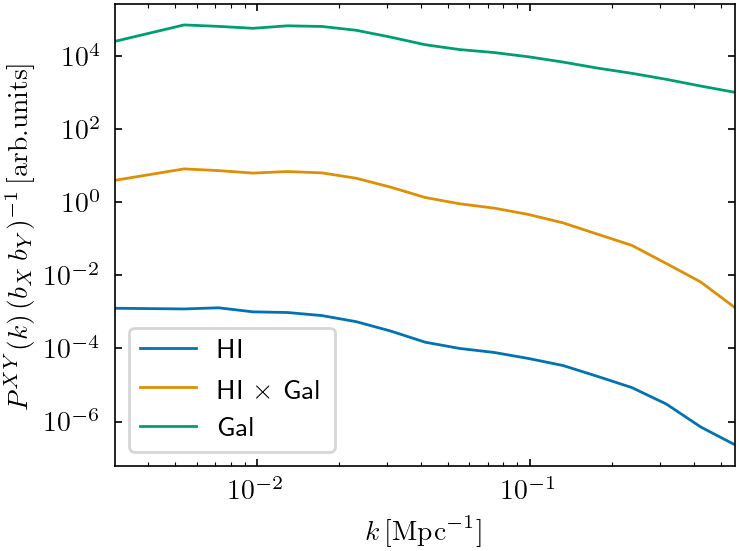

In [53]:
color = iter(Cs)

plt.loglog(kcenter, Pkhi - Pknoise, c=next(color), label="HI")
plt.loglog(kcenter, Pkhixgal, c=next(color), label=r"HI $\times$ Gal")
plt.loglog(kcenter, Pkgal, c=next(color), label="Gal")
plt.legend()
plt.xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P^{XY}(k)\,(b_X\,b_Y)^{-1}\,[\mathrm{arb. units}]$")

In [54]:
Pkhixgal


array([3.96483061e+00, 8.12804315e+00, 7.29206682e+00, 6.23819726e+00,
       6.87286035e+00, 6.31879701e+00, 4.50362606e+00, 2.56875799e+00,
       1.34160450e+00, 9.03165952e-01, 6.87135693e-01, 4.60360264e-01,
       2.72240736e-01, 1.33473793e-01, 6.58456821e-02, 2.10221577e-02,
       6.55538085e-03, 1.29086624e-03])

# Compare to meerklass predicition

In [ ]:
ps = PowerSpectrum(
        wproj=wcs,
        num_pix_x=num_pix_x,
        num_pix_y=num_pix_y,
        ra_range=ra_range,
        dec_range=dec_range,
        nu=nu_arr,
        tracer_bias_2=1.5,
        tracer_bias_1=1.5,
        mean_amp_1="average_hi_temp",
        omega_hi=5e-4,
        sigma_beam_ch=sigma_beam_new,
        sigma_v_1= 100, # in velocity units
        sigma_v_2= 100,
    )

ps.W_HI = np.ones_like(ps.W_HI)
ps.w_HI = np.ones_like(ps.w_HI)
ps.trim_map_to_range()

ps.taper_func = getattr(windows, window_name)
ps.grid_scheme = "cic"


ps.downres_factor_transverse = 3
ps.downres_factor_radial = 6
ps.get_enclosing_box()

ps.include_sky_sampling = [True, False]
ps.compensate = [True, True]
ps.include_beam = [True, False]

/home/sefa/Desktop/projects/meerklass/meerklass/lib/python3.12/site-packages/meer21cm/power.py:1222: SyntaxWarning: invalid escape sequence '\p'
  """


TypeError: unsupported operand type(s) for *: 'NoneType' and 'float'

In [60]:
ps.kparabins = kparabins
ps.kperpbins = kperpbins

array([ 734.32853136, 2405.926011  ,  830.18114564])

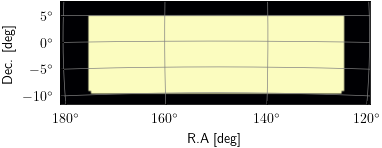

In [61]:
ps.get_enclosing_box()
plot_map(ps.W_HI,ps.wproj,have_cbar=False)
ps.box_len

Text(0, 0.5, '$P^\\mathrm{gal}(k)\\,[\\mathrm{Mpc}^3]$')

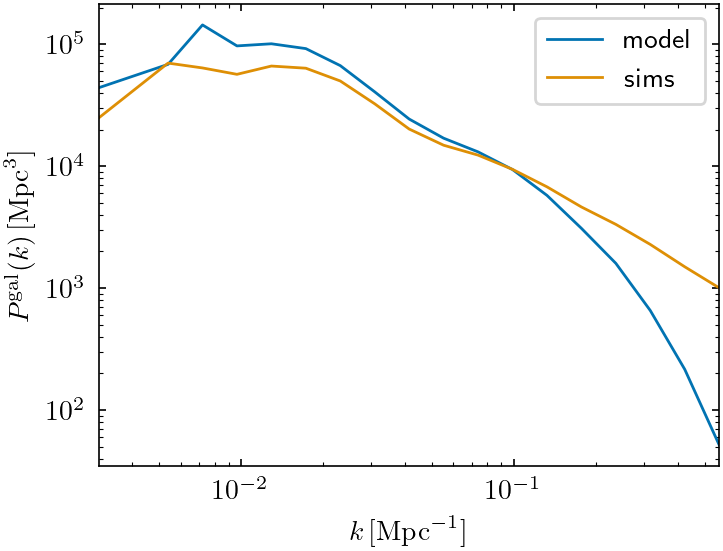

In [62]:
pkmodel, _, _ = binned_statistic(
    ps.kmode.flatten(), ps.auto_power_tracer_2_model.flatten(),
    statistic="mean", bins=kedges)
pkmodel = pkmodel[Nmask]


color = iter(Cs)
plt.loglog(kcenter, pkmodel, c=next(color), label="model")
plt.loglog(kcenter, Pkgal, c=next(color), label="sims")
plt.legend()
plt.xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P^\mathrm{gal}(k)\,[\mathrm{Mpc}^3]$")

Text(0, 0.5, '$P^{\\mathrm{HI}}(k)\\,[\\mathrm{mK}^2\\,\\mathrm{Mpc}^3]$')

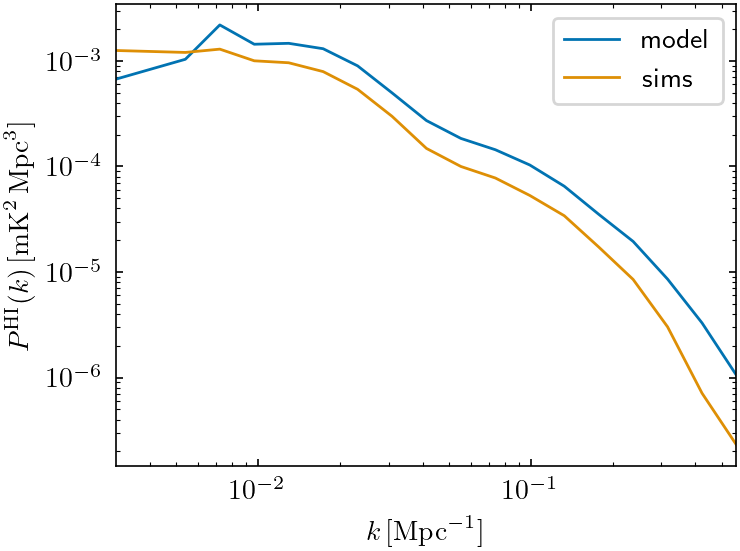

In [41]:
pkmodel, _, _ = binned_statistic(
    ps.kmode.flatten(), ps.auto_power_tracer_1_model.flatten(),
    statistic="mean", bins=kedges)
pkmodel = pkmodel[Nmask]


color = iter(Cs)
plt.loglog(kcenter, pkmodel, c=next(color), label="model")
plt.loglog(kcenter, Pkhi - Pknoise, c=next(color), label="sims")
plt.legend()
plt.xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P^{\mathrm{HI}}(k)\,[\mathrm{mK}^2\,\mathrm{Mpc}^3]$")

Text(0, 0.5, '$P^{\\mathrm{HI}\\times\\mathrm{gal}}(k)\\,[\\mathrm{mK}\\,\\mathrm{Mpc}^3]$')

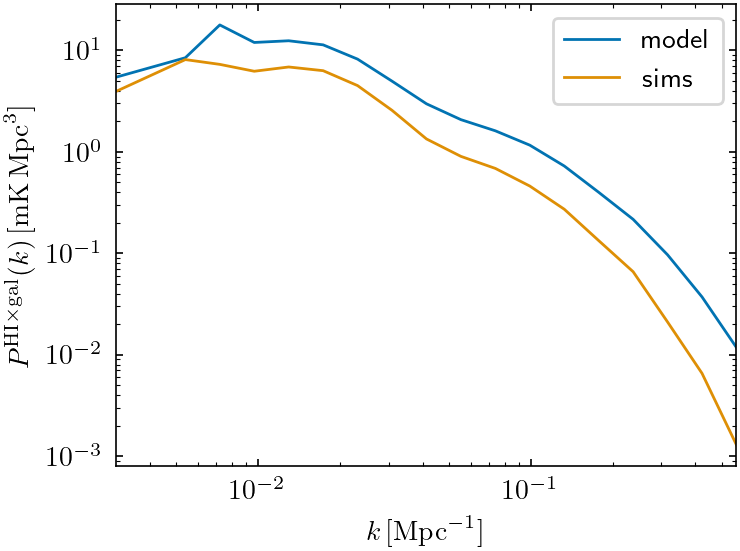

In [42]:
pkmodel, _, _ = binned_statistic(
    ps.kmode.flatten(), ps.cross_power_tracer_model.flatten(),
    statistic="mean", bins=kedges)
pkmodel = pkmodel[Nmask]


color = iter(Cs)
plt.loglog(kcenter, pkmodel, c=next(color), label="model")
plt.loglog(kcenter, Pkhixgal, c=next(color), label="sims")
plt.legend()
plt.xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P^{\mathrm{HI}\times\mathrm{gal}}(k)\,[\mathrm{mK}\,\mathrm{Mpc}^3]$")

# Additional Power spectra

Text(0, 0.5, '$P(k)\\,[\\mathrm{K}^2\\,\\mathrm{Mpc}^3]$')

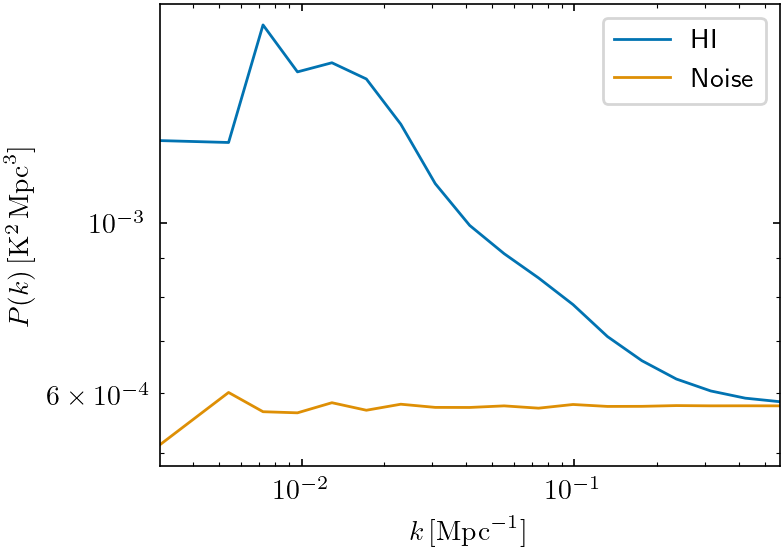

In [ ]:
color = iter(Cs)

plt.loglog(kcenter, Pkhi, c=next(color), label="HI")
plt.loglog(kcenter, Pknoise, c=next(color), label="Noise")

plt.legend()
plt.xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P(k)\,[\mathrm{K}^2\,\mathrm{Mpc}^3]$")

In [ ]:
Pknoisexgal = extract_mean("pnoisexgal")

Text(0, 0.5, '$P(k)\\,[\\mathrm{K}^2\\,\\mathrm{Mpc}^3]$')

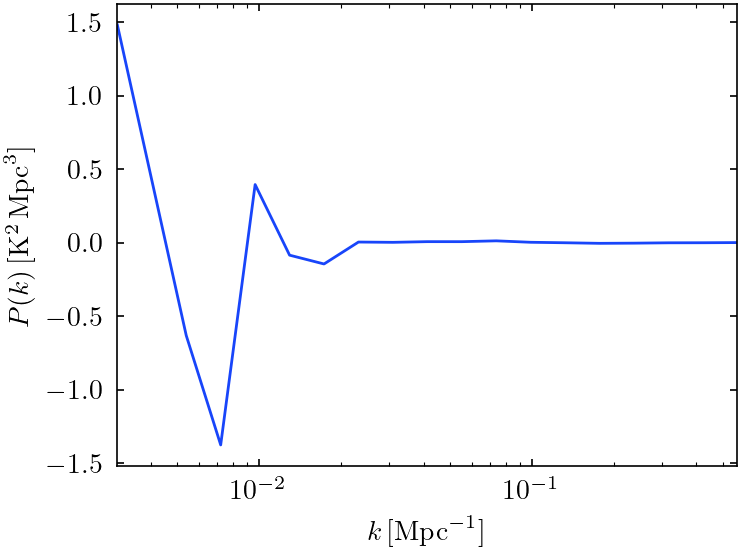

In [ ]:
plt.semilogx(kcenter, Pknoisexgal)

plt.xlabel(r"$k\,[\mathrm{Mpc}^{-1}]$")
plt.ylabel(r"$P(k)\,[\mathrm{K}^2\,\mathrm{Mpc}^3]$")

# Compare model to mock

In [ ]:
from scipy.stats import binned_statistic_2d
import multiprocessing as mp

In [ ]:
kx, ky, kz = ps.k_vec
notkmasksimple = np.logical_or(
    np.logical_or(
        np.array(kx)[:, None, None]==0, np.array(ky)[:, None]==0
    ),
    np.array(kz)==0,
)

kparr = ps.kmode * ps.mumode
kperp = ps.kmode * np.sqrt(1 - np.clip(ps.mumode**2,0,1))

kparrc = 0.5 * (kparabins[1:] + kparabins[:-1]) # Bin centers
kperpc = 0.5 * (kperpbins[1:] + kperpbins[:-1]) # Bin centers
k1dc = 0.5 * (k1dbins[1:] + k1dbins[:-1])


np.mean(np.array(notkmasksimple, dtype=int)) # fraction of wavenumber whose wavenumber has at least one 0 component

0.1270338856545753

In [ ]:
def get_cy_power_sims(array):
    data = array[~notkmasksimple]
    output, _, _, _ = binned_statistic_2d(
        kparr[~notkmasksimple], kperp[~notkmasksimple], data, statistic="mean", bins=(kparabins, kperpbins)
    )
    return output

def get_1d_power_sims(array):
    data = array[~notkmasksimple]
    # print(data.shape, kmode[~notkmasksimple].shape)
    output, _, _ = binned_statistic(
        kmode[~notkmasksimple], data, statistic="mean", bins=k1dbins
    )
    return output

In [ ]:
Pknoise_2d_sims_arr = []
with mp.Pool(14) as p:
    for output in p.map(get_cy_power_sims, data["pnoise"]):
        Pknoise_2d_sims_arr.append(output)
Pknoise_2d_sims = np.mean(
    np.array(Pknoise_2d_sims_arr), axis=0
)

In [ ]:
Pkhi_2d_sims_arr = []
with mp.Pool(14) as p:
    for output in p.map(get_cy_power_sims, data["phi"]):
        Pkhi_2d_sims_arr.append(output)
Pkhi_2d_sims = np.mean(
    np.array(Pkhi_2d_sims_arr), axis=0
)

Pkhi_2d_model, _, _, _ = binned_statistic_2d(
    kparr[~notkmasksimple], kperp[~notkmasksimple], ps.auto_power_tracer_1_model[~notkmasksimple],
    statistic="mean", bins=(kparabins, kperpbins),
)

In [ ]:
phimodcy_arr = bin_3d_to_cy(
    ps.auto_power_tracer_1_model, ps.k_perp, ps.kperpbins, vectorize=False, weights=np.array(~notkmasksimple, dtype=float)
)
phimodcy_arr = bin_3d_to_cy(
    phimodcy_arr, np.abs(ps.k_para), ps.kparabins, vectorize=False)

/home/sefa/Desktop/projects/meerklass/meerklass/lib/python3.12/site-packages/meer21cm/power.py:2037: RuntimeWarning: invalid value encountered in divide
  pscy = pscy / np.sum(weights, 0)[None]


<>:24: SyntaxWarning: invalid escape sequence '\%'
<>:24: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_122986/2948983258.py:24: SyntaxWarning: invalid escape sequence '\%'
  cbar2.set_label("Residual $[\%]$")


Text(0.5, 1.0, 'Binning Meer21cm')

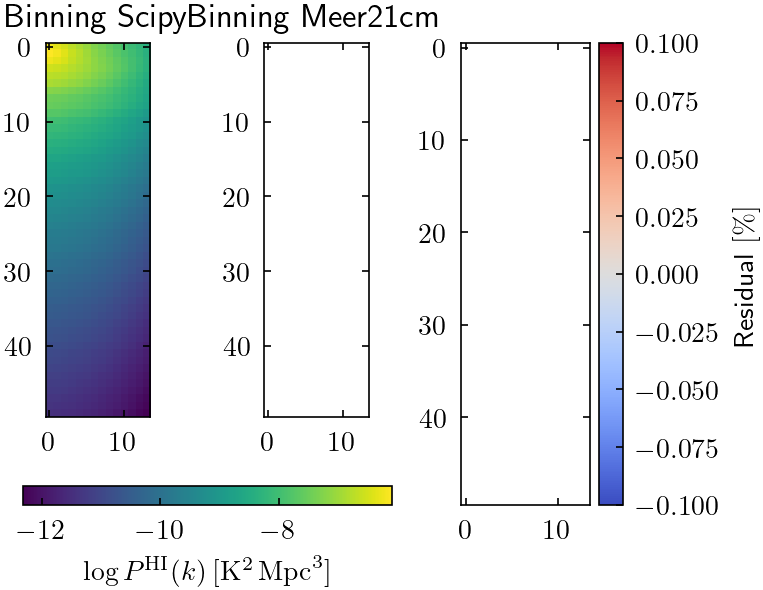

In [ ]:
fig, axs = plt.subplots(1, 3)

# Compute logs once
log_A = np.log(Pkhi_2d_model)
log_B = np.log(phimodcy_arr).T
residual = (np.exp(log_A - log_B) - 1) * 100

# Shared normalization for first two
vmin = min(log_A.min(), log_B.min())
vmax = max(log_A.max(), log_B.max())

im0 = axs[0].imshow(log_A, vmin=vmin, vmax=vmax)
im1 = axs[1].imshow(log_B, vmin=vmin, vmax=vmax)

rmax = np.abs(residual).max()
im2 = axs[2].imshow(residual, vmin= -rmax, vmax=rmax, cmap="coolwarm")

# One colorbar for first two plots
cbar1 = fig.colorbar(im0, ax=axs[:2], orientation='horizontal', fraction=0.04)
cbar1.set_label(r"$\log P^\mathrm{HI}(k)\,[\mathrm{K}^2\,\mathrm{Mpc}^3]$")

# One colorbar for residual
cbar2 = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cbar2.set_label("Residual $[\%]$")
axs[0].set_title("Binning Scipy")
axs[1].set_title("Binning Meer21cm")

In [ ]:
Pkhixgal_2d_sims_arr = []
with mp.Pool(14) as p:
    for output in p.map(get_cy_power_sims, data["phixgal"]):
        Pkhixgal_2d_sims_arr.append(output)
Pkhixgal_2d_sims = np.mean(
    np.array(Pkhixgal_2d_sims_arr), axis=0
)

Pkhixgal_2d_model, _, _, _ = binned_statistic_2d(
    kparr[~notkmasksimple], kperp[~notkmasksimple], ps.cross_power_tracer_model[~notkmasksimple],
    statistic="mean", bins=(kparabins, kperpbins),
)

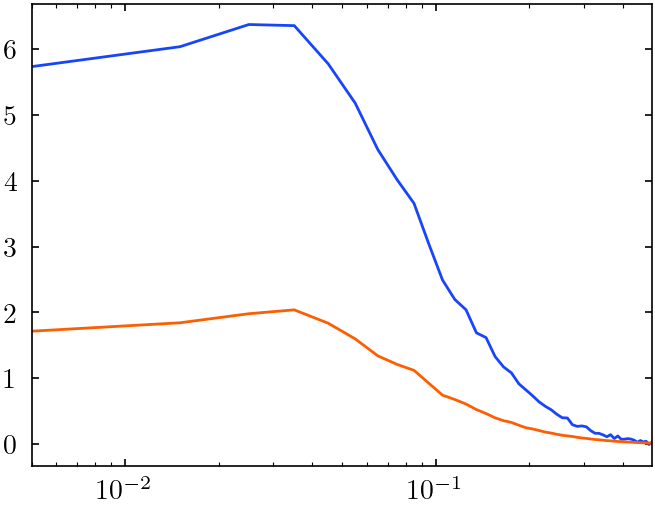

In [ ]:
plt.semilogx(kparrc, Pkhixgal_2d_sims[:, 9])
plt.semilogx(kparrc, Pkhixgal_2d_model[:, 9])

<>:29: SyntaxWarning: invalid escape sequence '\%'
<>:29: SyntaxWarning: invalid escape sequence '\%'
/tmp/ipykernel_122986/2095001438.py:29: SyntaxWarning: invalid escape sequence '\%'
  cbar2.set_label("Residual [\%]")
/tmp/ipykernel_122986/2095001438.py:5: RuntimeWarning: invalid value encountered in log
  log_B = np.log(Pkhixgal_2d_sims)


Text(0.5, 1.0, 'Simulation')

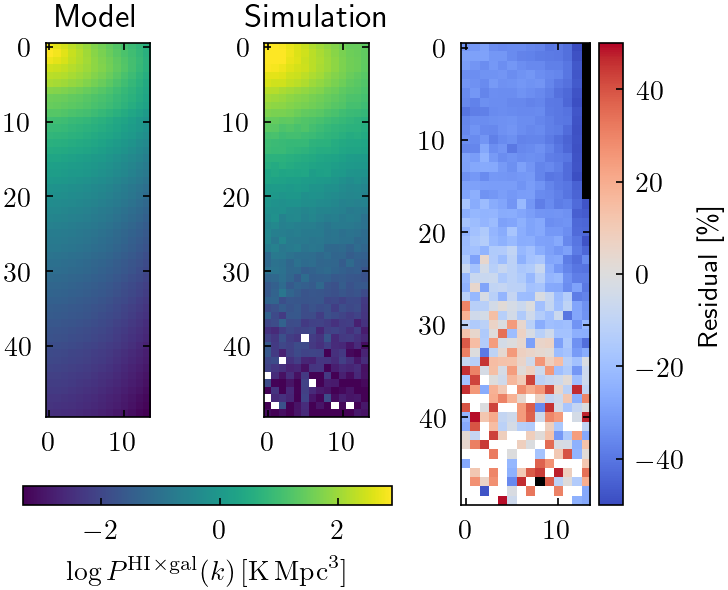

In [ ]:
fig, axs = plt.subplots(1, 3)

# Compute logs once
log_A = np.log(Pkhixgal_2d_model)
log_B = np.log(Pkhixgal_2d_sims)
residual = (np.exp(log_A - log_B) - 1) * 100

# Shared normalization for first two
vmin = min(log_A.min(), log_B.min())
vmax = max(log_A.max(), log_B.max())

im0 = axs[0].imshow(log_A, vmin=vmin, vmax=vmax)
im1 = axs[1].imshow(log_B, vmin=vmin, vmax=vmax)


import matplotlib.cm as cm
cmap = cm.coolwarm.copy()
cmap.set_under("black")
cmap.set_over("white")

im2 = axs[2].imshow(residual, vmin= -50, vmax=50, cmap=cmap)

# One colorbar for first two plots
cbar1 = fig.colorbar(im0, ax=axs[:2], orientation='horizontal', fraction=0.04)
cbar1.set_label(r"$\log P^{\mathrm{HI}\times\mathrm{gal}}(k)\,[\mathrm{K}\,\mathrm{Mpc}^3]$")

# One colorbar for residual
cbar2 = fig.colorbar(im2, ax=axs[2], orientation='vertical')
cbar2.set_label("Residual [\%]")
axs[0].set_title("Model")
axs[1].set_title("Simulation")

In [ ]:
Pkhixgal_1d_sims_arr = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, data["phixgal"]):
        Pkhixgal_1d_sims_arr.append(output)
Pkhixgal_1d_sims_arr = np.array(Pkhixgal_1d_sims_arr)

Nsims, Nk = Pkhixgal_1d_sims_arr.shape

DPkhixgal_1d_sims_arr = Pkhixgal_1d_sims_arr - Pkhixgal_1d_sims_arr.mean(0)
cov_HI = 1 / (Nsims - 1) * np.einsum("ij, ik -> jk", DPkhixgal_1d_sims_arr, DPkhixgal_1d_sims_arr)

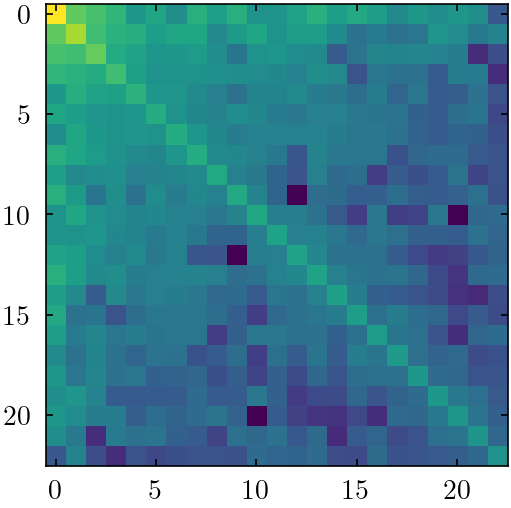

In [ ]:
plt.imshow(np.log(np.abs(cov_HI)))

In [ ]:
corr = cov_HI / np.sqrt(np.outer(np.diag(cov_HI),np.diag(cov_HI)))

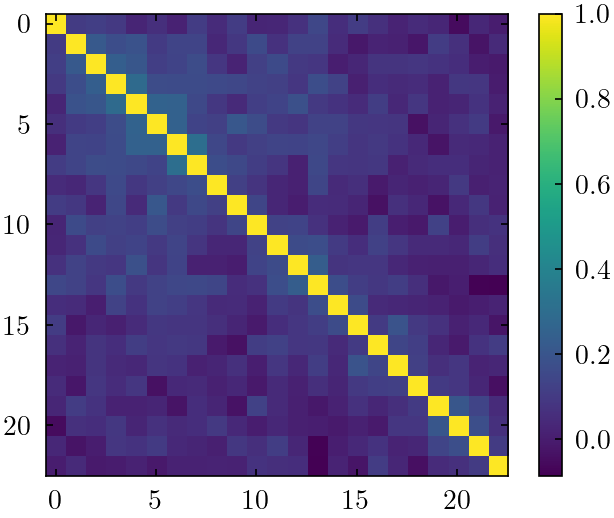

In [ ]:
plt.imshow(corr)
plt.colorbar()

Text(0.5, 0, 'Wavenumber $k\\,[\\mathrm{Mpc}^{-1}]$')

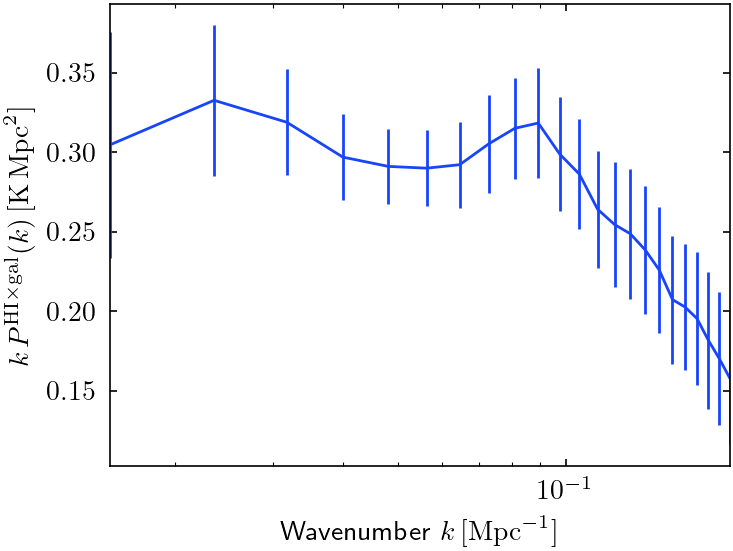

In [ ]:
plt.errorbar(k1dc, k1dc * Pkhixgal_1d_sims_arr.mean(0), yerr= k1dc * np.sqrt(np.diag(cov_HI)))
plt.semilogx()
plt.ylabel(r"$k\,P^{\mathrm{HI}\times\mathrm{gal}}(k)\,[\mathrm{K}\,\mathrm{Mpc}^2]$")
plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")


$$ P_{BB}(a_i) \to P^{\rm sys}_{BB} \to P - P^{\rm sys}_{BB}
$$

In [ ]:
Pkhi_1d_sims_arr = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, data["phi"]):
        Pkhi_1d_sims_arr.append(output)
Pkhi_1d_sims_arr = np.array(Pkhi_1d_sims_arr)

Nsims, Nk = Pkhi_1d_sims_arr.shape

DPkhi_1d_sims_arr = Pkhi_1d_sims_arr - Pkhi_1d_sims_arr.mean(0)
cov = 1 / (Nsims - 1) * np.einsum("ij, ik -> jk", DPkhi_1d_sims_arr, DPkhi_1d_sims_arr)

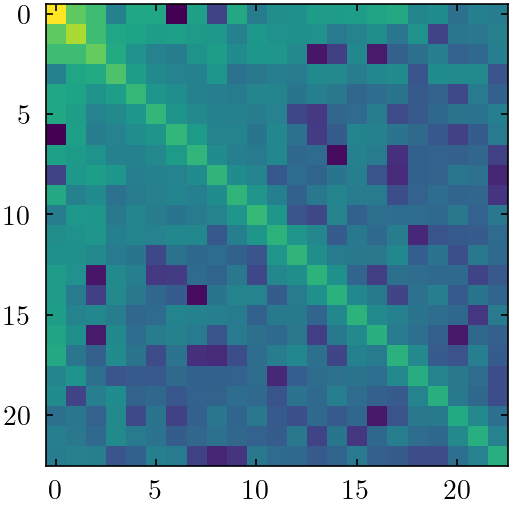

In [ ]:
plt.imshow(np.log(np.abs(cov)))

In [ ]:
corr = cov / np.sqrt(np.outer(np.diag(cov),np.diag(cov)))

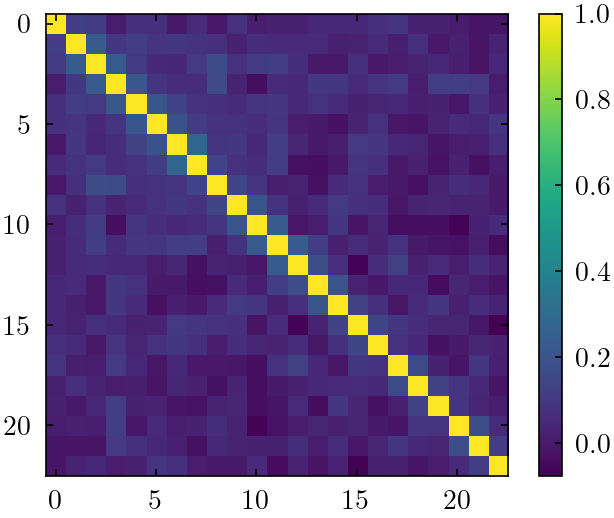

In [ ]:
plt.imshow(corr)
plt.colorbar()

In [ ]:
Pknoise_1d_sims_arr = []
with mp.Pool(14) as p:
    for output in p.map(get_1d_power_sims, data["pnoise"]):
        Pknoise_1d_sims_arr.append(output)
Pknoise_1d_sims_arr = np.array(Pknoise_1d_sims_arr)

Text(0.5, 0, 'Wavenumber $k\\,[\\mathrm{Mpc}^{-1}]$')

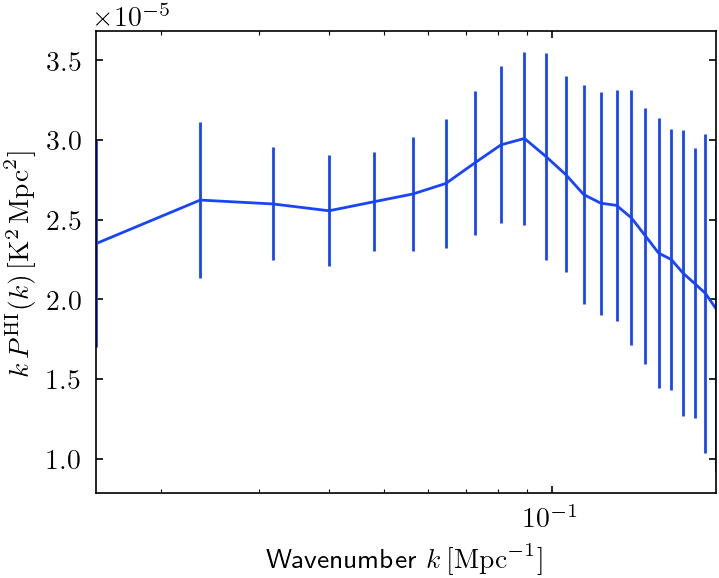

In [ ]:
plt.errorbar(k1dc, k1dc * (Pkhi_1d_sims_arr.mean(0) - Pknoise_1d_sims_arr.mean(0)), yerr= k1dc * np.sqrt(np.diag(cov)))
plt.semilogx()
plt.ylabel(r"$k\,P^{\mathrm{HI}}(k)\,[\mathrm{K}^2\,\mathrm{Mpc}^2]$")
plt.xlabel(r"Wavenumber $k\,[\mathrm{Mpc}^{-1}]$")

In [ ]:
N, _, _ = binned_statistic(kmode[~notkmasksimple], [], "count", k1dbins)
N

array([ 40., 104., 232., 372., 536., 556., 484., 460., 428., 408., 420.,
       404., 392., 388., 384., 368., 396., 368., 380., 384., 380., 380.,
       384.])

In [ ]:
cosmo = Class_cosmo_model(ps.fiducial_cosmology)

{}


In [ ]:
T2 = ps.average_hi_temp**2

kclean, muclean = ps.kmode[~notkmasksimple], ps.mumode[~notkmasksimple]

kaiser = (ps.tracer_bias_1 + cosmo.f_lin(ps.z) * muclean**2)**2

sigmaV = cosmo.sigmav(ps.z)
pqnl = cosmo.Pk_QNL(kclean, muclean, ps.z, sigmaV).squeeze(-1)
pnw = cosmo.Pk_nw(kclean, ps.z).squeeze(-1)

Ps_rsd_noobs_class = T2 * kaiser * pqnl
Ps_nw_rsd_noobs_class = T2 * kaiser * pnw


In [ ]:
ps.sigma_beam_ch = 0.4

beam2 = ps.beam_attenuation()[~notkmasksimple]**2

ps.grid_scheme = "cic"
gridwin = ps.gridding_compensation()[~notkmasksimple]**2

ps.sampling_resol = [
    ps.pix_resol_in_mpc,
    ps.pix_resol_in_mpc,
    ps.los_resol_in_mpc, # Is this in fid or true
]
pixwin = ps.map_sampling()[~notkmasksimple]**2

Ps_rsd_noconv_class =  Ps_rsd_noobs_class * beam2 * gridwin * pixwin
Ps_nw_noconv_class = Ps_nw_rsd_noobs_class * beam2 * gridwin * pixwin

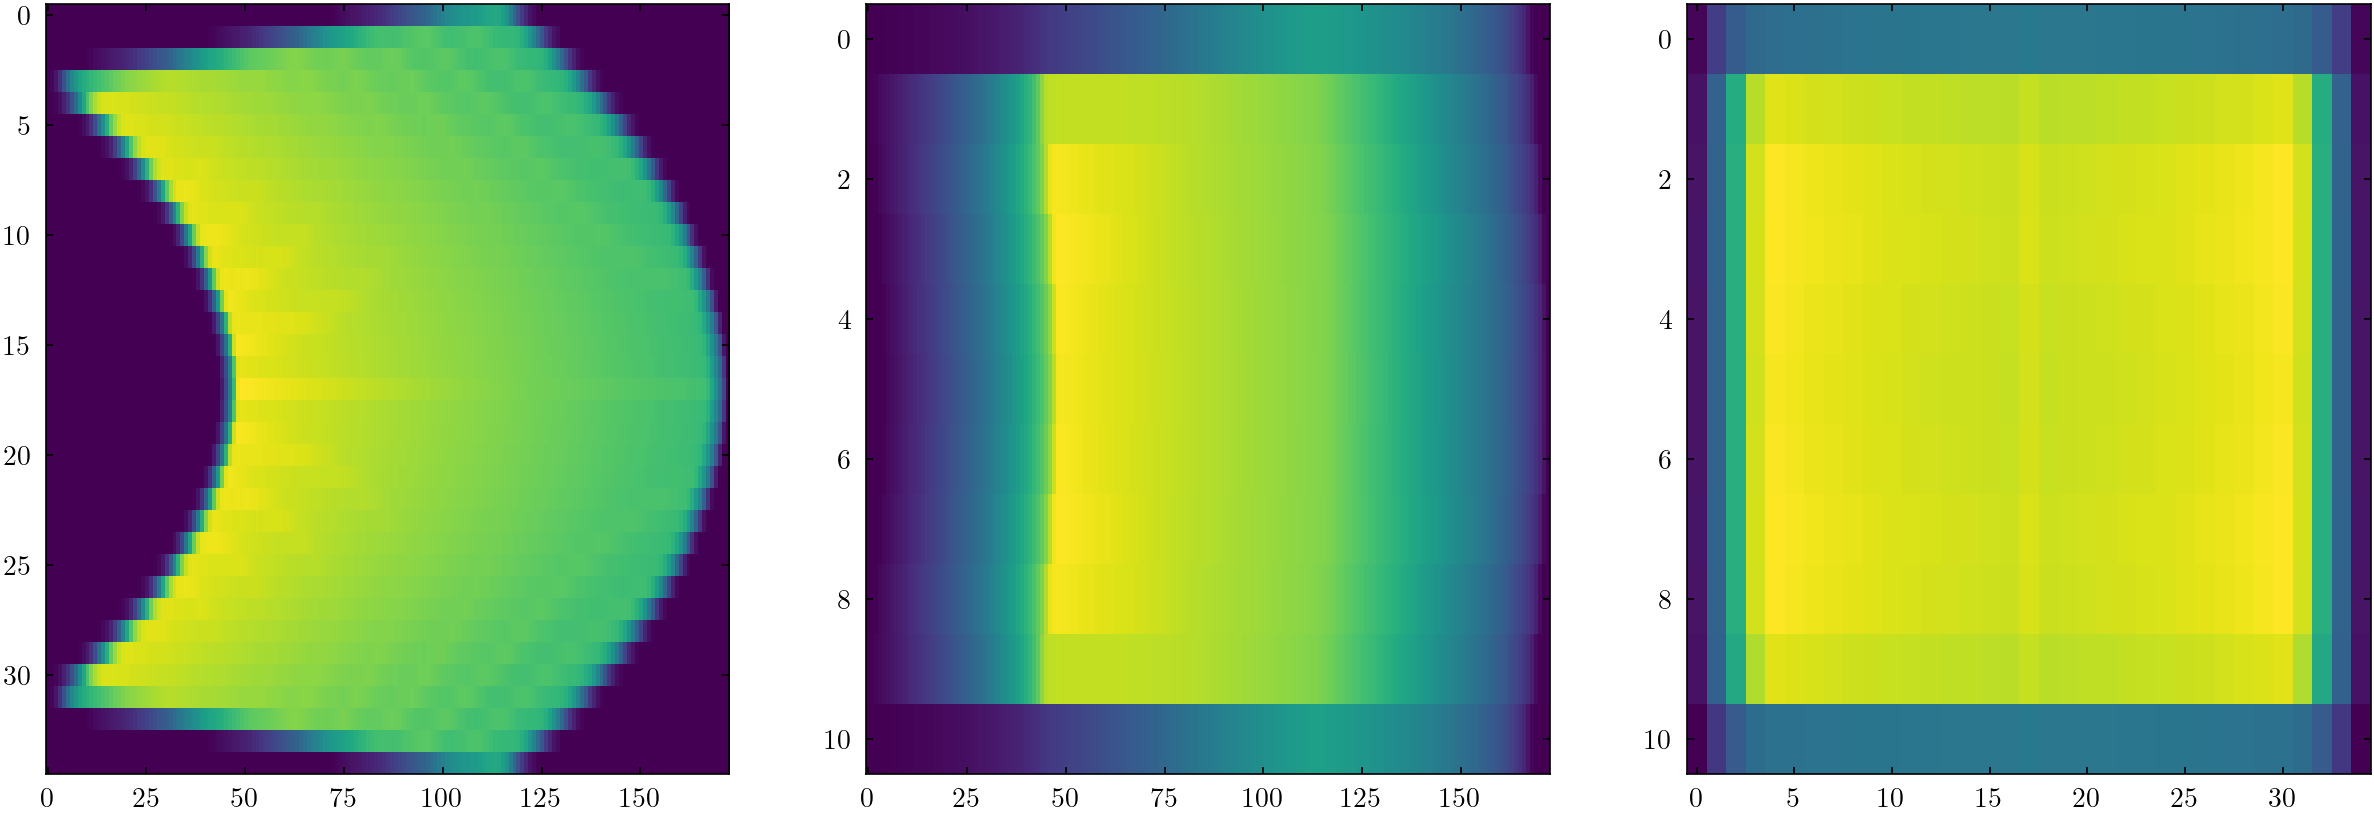

In [ ]:
ps.grid_data_to_field()

fig, axes = plt.subplots(1,3,figsize=(15,5))
for i, ax in enumerate(axes):
    ax.imshow(ps.counts_in_box.mean(i),aspect='auto')

In [ ]:
ps.weights_1 = ps.counts_in_box.astype('float')

In [ ]:
def restore_shape(pk):
    normal = np.zeros_like(kmode)
    normal[~notkmasksimple] = pk
    return normal

Ps_survey_model = get_modelpk_conv(
    restore_shape(Ps_rsd_noconv_class),
    ps.weights_1,
    ps.weights_1,
)[~notkmasksimple]

Ps_nw_survey_model = get_modelpk_conv(
    restore_shape(Ps_nw_noconv_class),
    ps.weights_1,
    ps.weights_1,
)[~notkmasksimple]

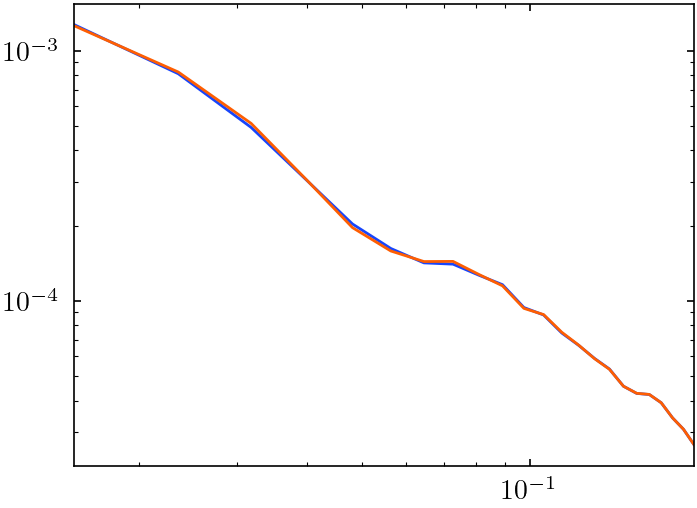

In [ ]:
Ps_survey_model_1d, _, _ = binned_statistic(kclean, Ps_survey_model, "mean", k1dbins)
plt.loglog(k1dc, Ps_survey_model_1d)

Ps_nw_survey_model_1d, _, _ = binned_statistic(kclean, Ps_nw_survey_model, "mean", k1dbins)
plt.loglog(k1dc, Ps_nw_survey_model_1d)

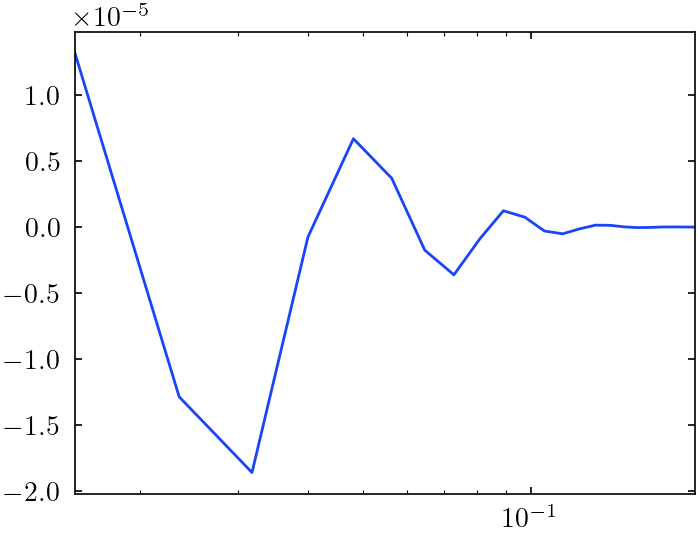

In [ ]:
#plt.errorbar(k1dc, Ps_survey_model_1d - Ps_nw_survey_model_1d, np.sqrt(np.diag(cov_HI)))
plt.semilogx(k1dc, Ps_survey_model_1d - Ps_nw_survey_model_1d) #np.sqrt(np.diag(cov_HI)))


# Other comparasions

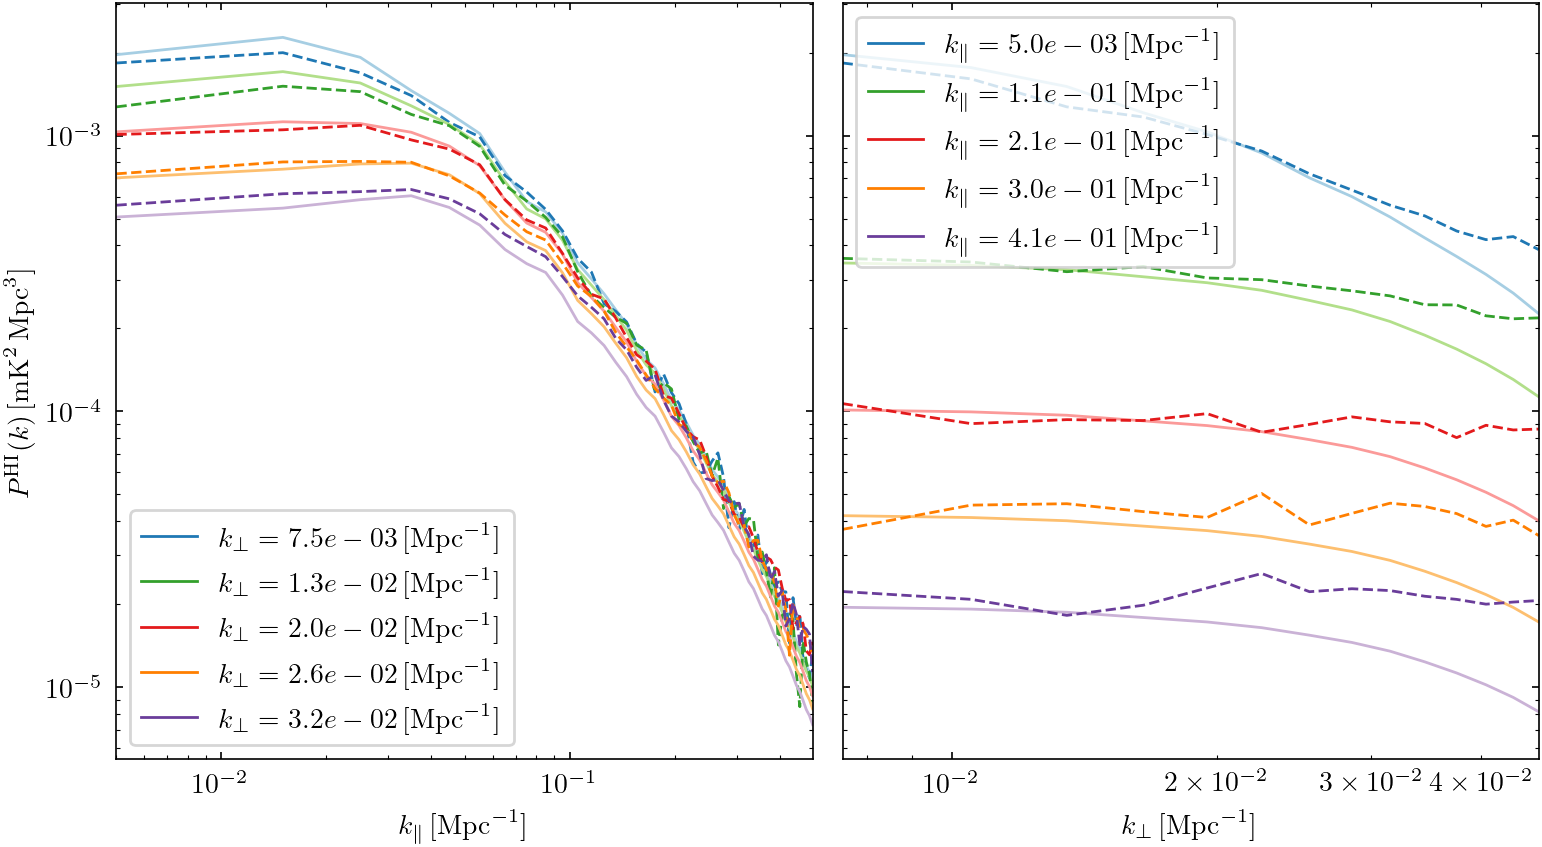

In [ ]:
color = iter(Cp)

fw, fh = plt.rcParams['figure.figsize'] 
fig, axs = plt.subplots(
    nrows=1, ncols=2, sharex=False,
    sharey="row",
    figsize=(2*fw, 1.5*fh)
)

curvestoplot = 5
for i in range(curvestoplot):
    ikperp = i * int(len(kperpc)//curvestoplot)

    c = next(color)
    axs[0].loglog(
        kparrc,
        Pkhi_2d_model[:, ikperp],
        c=c
    )

    c = next(color)
    axs[0].loglog(
        kparrc,
        (Pkhi_2d_sims - Pknoise_2d_sims)[:, ikperp],
        c=c, ls="--"
    )

    axs[0].plot([], [], c=c,
        label=r"$k_\perp={:.1e}\,[\mathrm{{Mpc}}^{{-1}}]$".format(kperpc[ikperp])
    )

axs[0].legend()
axs[0].set_xlabel(r"$k_\|\,[\mathrm{Mpc}^{-1}]$")
axs[0].set_ylabel(r"$P^\mathrm{HI}(k)\,[\mathrm{mK}^2\,\mathrm{Mpc}^{3}]$")

color = iter(Cp)  # reset color cycle

for i in range(curvestoplot):
    ikpar = i * int(len(kparrc)//curvestoplot)

    c = next(color)
    axs[1].loglog(
        kperpc,
        Pkhi_2d_model[ikpar, :],
        c=c
    )

    c = next(color)
    axs[1].loglog(
        kperpc,
        (Pkhi_2d_sims - Pknoise_2d_sims)[ikpar, :],
        c=c, ls="--"
    )

    axs[1].plot([], [], c=c,
        label=r"$k_\|={:.1e}\,[\mathrm{{Mpc}}^{{-1}}]$".format(kparrc[ikpar])
    )

axs[1].legend()
axs[1].set_xlabel(r"$k_\perp\,[\mathrm{Mpc}^{-1}]$")

plt.tight_layout()
plt.show()